In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%cd .. 
# %cd ..

/home/stan/documents/TNTM_reproduce


In [3]:
import torch
import pickle


In [4]:
# Set random seeds for reproducibility
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seeds set to {SEED}")


Random seeds set to 42


In [5]:
%ls

Ablations/  Code/  README.md  requirements.txt
Benchmark/  Data/  msc/       tntm_environment.yml


In [6]:
from Benchmark.TopMost2OctisAdapter import TopMost2OctisAdapter

from topmost.models import ProdLDA


/home/stan/miniconda3/envs/tntm_reproduce/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# with open("C:\\Users\\arik_\\\Documents\\Dokumente\\Job_Clausthal\\TNTM\\TNTM_Revision_TNNLS\\TNTM\\Data\\DataOctis2\\octis_dataset_20ng.pickle", "rb") as file:
#    bow_data = pickle.load(file)

with open(
    "Data/DataOctis2/octis_dataset_20ng.pickle",
    "rb",
) as file:
    octis_dataset = pickle.load(file)


In [8]:
from Code.Evaluate.Metrics import score_all, get_tw_embeddings


with open(
    "Data/DataResults_BERT_octis/cleaned_embedding_df_20ng_BERT.pickle",
    "rb",
) as f:
    embedding_df = pickle.load(f)


[nltk_data] Downloading package brown to /home/stan/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package stopwords to /home/stan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
corpus = octis_dataset.get_corpus()
vocab = octis_dataset.get_vocabulary()


In [10]:
len(corpus), len(vocab)


(18846, 3350)

In [11]:
corpus_red = corpus[:100]
vocab_red = [word for doc in corpus_red for word in doc]
vocab_red = list(set(vocab_red))


In [12]:
octis_dataset._corpus = corpus_red
octis_dataset._vocabulary = vocab_red


In [13]:
def data2params_prodlda(corpus, vocab):
    return {
        "vocab_size": len(vocab),
    }


In [14]:
model = TopMost2OctisAdapter(
    model_topmost=ProdLDA,
    model_kwargs={"num_topics": 10},
    data2_additional_kwargs=data2params_prodlda,
    batch_size=512,
)


In [15]:
len(vocab_red)


2449

In [16]:
# Create the topic-word embeddings
tw_emb = get_tw_embeddings(octis_dataset)


100%|██████████| 48018/48018 [05:11<00:00, 154.14it/s]


In [17]:
res = model.fit(octis_dataset)


parsing texts: 100%|██████████| 100/100 [00:00<00:00, 18028.39it/s]
2025-06-23 09:53:33,700 - TopMost - Real vocab size: 2204
2025-06-23 09:53:33,701 - TopMost - Real training size: 100 	 avg length: 121.460


2204


100%|██████████| 200/200 [00:00<00:00, 259.21it/s]


In [18]:
evaluation_result = score_all(
    dataset=octis_dataset,
    tw_emb=tw_emb,
    n_words=10,
    result={"topics": res[0], "topic-word-matrix": res[1]},
)


100%|██████████| 5/5 [00:19<00:00,  3.81s/it]


In [19]:
evaluation_result


{'NPMI': -0.005309157179287136,
 'WE_CO_PW': 0.03450730986065335,
 'Embedding_Coherence': 0.23652532696723938,
 'WESS': 0.26208361983299255,
 'Topic Diversity': 0.99}

In [20]:
# Direct import from local module
from Benchmark.Benchmark import Benchmark


In [21]:
# Define the common set of topic numbers to test across all models
n_topics = [10, 15, 20, 50, 100, 200]

bench = Benchmark(
    octis_dataset=octis_dataset,
    embedding_df=embedding_df,
    models=[ProdLDA],
    model_specific_data2params_fun_list=[data2params_prodlda],
    n_topics=n_topics,
    batch_size=256,
    seed=SEED,  # Use the same seed we defined earlier
)


In [22]:
r = bench.run()


parsing texts: 100%|██████████| 100/100 [00:00<00:00, 7940.00it/s]


2204


100%|██████████| 200/200 [00:03<00:00, 61.07it/s] 

100%|██████████| 10/10 [00:00<00:00, 42153.81it/s]

100%|██████████| 5/5 [00:20<00:00,  4.12s/it]


Done with model <class 'topmost.models.basic.ProdLDA.ProdLDA'> and n_topics 10


parsing texts: 100%|██████████| 100/100 [00:00<00:00, 13271.01it/s]


...

Done with model <class 'topmost.models.basic.ProdLDA.ProdLDA'> and n_topics 100


parsing texts: 100%|██████████| 100/100 [00:00<00:00, 17409.53it/s]


2204


100%|██████████| 200/200 [00:00<00:00, 258.76it/s]

100%|██████████| 200/200 [00:00<00:00, 100909.52it/s]

100%|██████████| 1/1 [07:32<00:00, 453.00s/it]

Done with model <class 'topmost.models.basic.ProdLDA.ProdLDA'> and n_topics 200


In [23]:
r


{(topmost.models.basic.ProdLDA.ProdLDA, 10): {'NPMI': -0.005309157179287136,
  'WE_CO_PW': 0.03450730986065335,
  'Embedding_Coherence': 0.23652532696723938,
  'WESS': 0.26208361983299255,
  'Topic Diversity': 0.99},
 (topmost.models.basic.ProdLDA.ProdLDA, 15): {'NPMI': -0.021006466817744117,
  'WE_CO_PW': 0.03999557159565113,
  'Embedding_Coherence': 0.22580986320972443,
  'WESS': 0.2618240714073181,
  'Topic Diversity': 0.9533333333333334},
 (topmost.models.basic.ProdLDA.ProdLDA, 20): {'NPMI': -0.032679245770859344,
  'WE_CO_PW': 0.02674511121379004,
  'Embedding_Coherence': 0.20755222588777542,
  'WESS': 0.21753038465976715,
  'Topic Diversity': 0.88},
 (topmost.models.basic.ProdLDA.ProdLDA, 50): {'NPMI': -0.07375382260435442,
  'WE_CO_PW': 0.026917576763365005,
  'Embedding_Coherence': 0.19805497646331788,
  'WESS': 0.20832975208759308,
  'Topic Diversity': 0.774},
 (topmost.models.basic.ProdLDA.ProdLDA, 100): {'NPMI': -0.12852729282977549,
  'WE_CO_PW': 0.022799141486485798,
  'Em

In [24]:
# Let's add ETM and LDAGensimTrainer models to our benchmark
from topmost.models import ETM
import topmost


# Define parameter functions for ETM
def data2params_etm(corpus, vocab):
    return {
        "vocab_size": len(vocab),
        "embed_size": 200,  # Default embedding size
        "en_units": 800,  # Default encoder units
        "dropout": 0.0,  # Default dropout
    }


# Create new benchmark for ETM
bench_etm = Benchmark(
    octis_dataset=octis_dataset,
    embedding_df=embedding_df,
    models=[ETM],
    model_specific_data2params_fun_list=[data2params_etm],
    n_topics=n_topics,  # Use the same n_topics variable defined earlier
    batch_size=256,
    seed=SEED,
)

print("Running ETM benchmark...")
r_etm = bench_etm.run()


Running ETM benchmark...


parsing texts: 100%|██████████| 100/100 [00:00<00:00, 7170.12it/s]


2204


100%|██████████| 200/200 [00:00<00:00, 342.07it/s]

100%|██████████| 10/10 [00:00<00:00, 36921.69it/s]

100%|██████████| 5/5 [00:16<00:00,  3.38s/it]


Done with model <class 'topmost.models.basic.ETM.ETM'> and n_topics 10


...

Done with model <class 'topmost.models.basic.ETM.ETM'> and n_topics 100


parsing texts: 100%|██████████| 100/100 [00:00<00:00, 12919.86it/s]


2204


100%|██████████| 200/200 [00:00<00:00, 281.08it/s]

100%|██████████| 200/200 [00:00<00:00, 178139.90it/s]

100%|██████████| 1/1 [06:14<00:00, 374.85s/it]

Done with model <class 'topmost.models.basic.ETM.ETM'> and n_topics 200


In [25]:
# Now let's create a custom adapter for LDA using gensim directly
# Instead of using topmost.LDAGensimTrainer which has compatibility issues


class LDAAdapter:
    def __init__(self, num_topics):
        self.num_topics = num_topics

    def fit(self, dataset):
        # Import required libraries
        import gensim
        from gensim.corpora import Dictionary
        import numpy as np

        # Get corpus and vocabulary
        corpus = dataset._corpus
        vocab = dataset._vocabulary

        # Create a gensim dictionary
        dictionary = Dictionary(corpus)

        # Convert corpus to bag-of-words format that gensim expects
        bow_corpus = [dictionary.doc2bow(doc) for doc in corpus]

        # Train LDA model using gensim directly
        lda_model = gensim.models.LdaModel(
            bow_corpus,
            num_topics=self.num_topics,
            id2word=dictionary,
            passes=10,  # Number of passes through corpus
            alpha="symmetric",
        )

        # Get topics in the format expected by OCTIS
        top_words = []
        beta = np.zeros((self.num_topics, len(vocab)))

        # Create vocab to index mapping
        word2idx = {word: idx for idx, word in enumerate(vocab)}

        # Extract topics
        for topic_idx in range(self.num_topics):
            topic = lda_model.show_topic(topic_idx, topn=len(vocab))
            words = []
            for word, prob in topic:
                words.append(word)
                if word in word2idx:
                    beta[topic_idx, word2idx[word]] = prob
            top_words.append(words)

        return np.array(top_words), beta


# Create a function to generate LDAAdapter instances for different topic numbers
def create_lda_adapter(n_topics):
    return LDAAdapter(n_topics)


# Define parameters function for LDA (empty as parameters are handled in the adapter)
def data2params_lda(corpus, vocab):
    return {}


# Create a list of LDA adapters for different topic numbers
n_topics_lda = [10, 15, 20, 50, 100]
lda_models = [create_lda_adapter(n) for n in n_topics]

# Run evaluation for each LDA model manually
print("Running LDA evaluations...")
r_lda = {}

for model in lda_models:
    n_topics = model.num_topics
    print(f"Evaluating LDA with {n_topics} topics...")

    # Fit the model
    top_words, beta = model.fit(octis_dataset)

    # Evaluate
    eval_result = score_all(
        dataset=octis_dataset,
        tw_emb=tw_emb,
        n_words=10,
        result={"topics": top_words, "topic-word-matrix": beta},
    )

    # Store results
    r_lda[(f"LDA", n_topics)] = eval_result
    print(f"Done with LDA and n_topics {n_topics}")

print("LDA evaluation complete!")


Running LDA evaluations...
Evaluating LDA with 10 topics...


100%|██████████| 5/5 [00:33<00:00,  6.68s/it]


Done with LDA and n_topics 10
Evaluating LDA with 15 topics...


100%|██████████| 5/5 [00:31<00:00,  6.26s/it]


Done with LDA and n_topics 15
Evaluating LDA with 20 topics...


...

Done with LDA and n_topics 50
Evaluating LDA with 100 topics...


100%|██████████| 5/5 [00:33<00:00,  6.60s/it]


Done with LDA and n_topics 100
Evaluating LDA with 200 topics...


100%|██████████| 5/5 [00:42<00:00,  8.56s/it]


Done with LDA and n_topics 200
LDA evaluation complete!


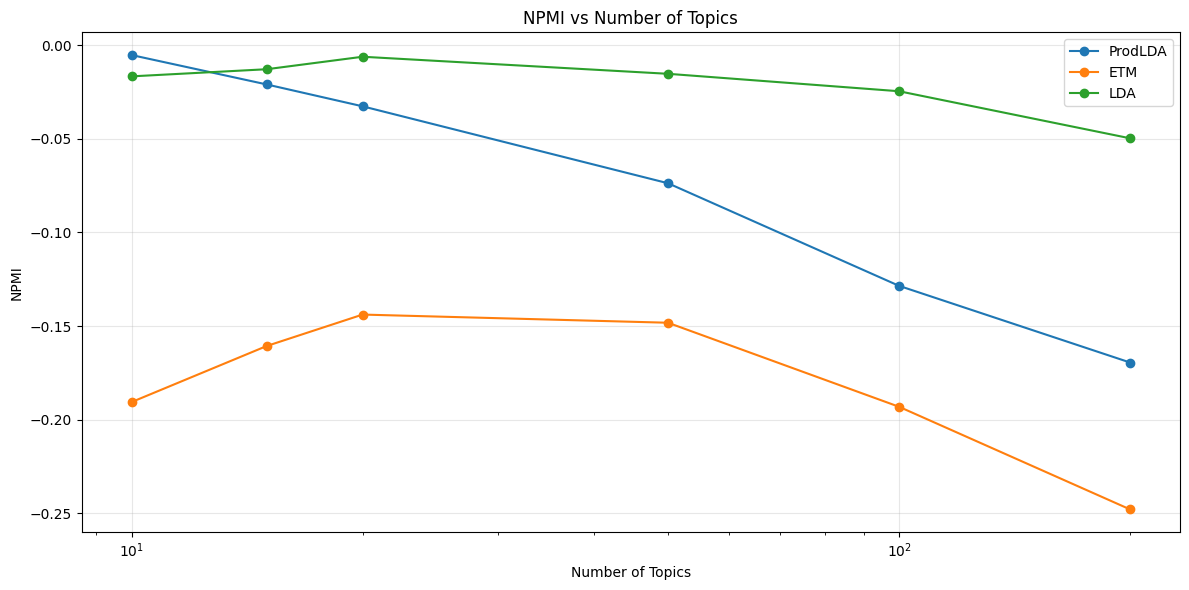

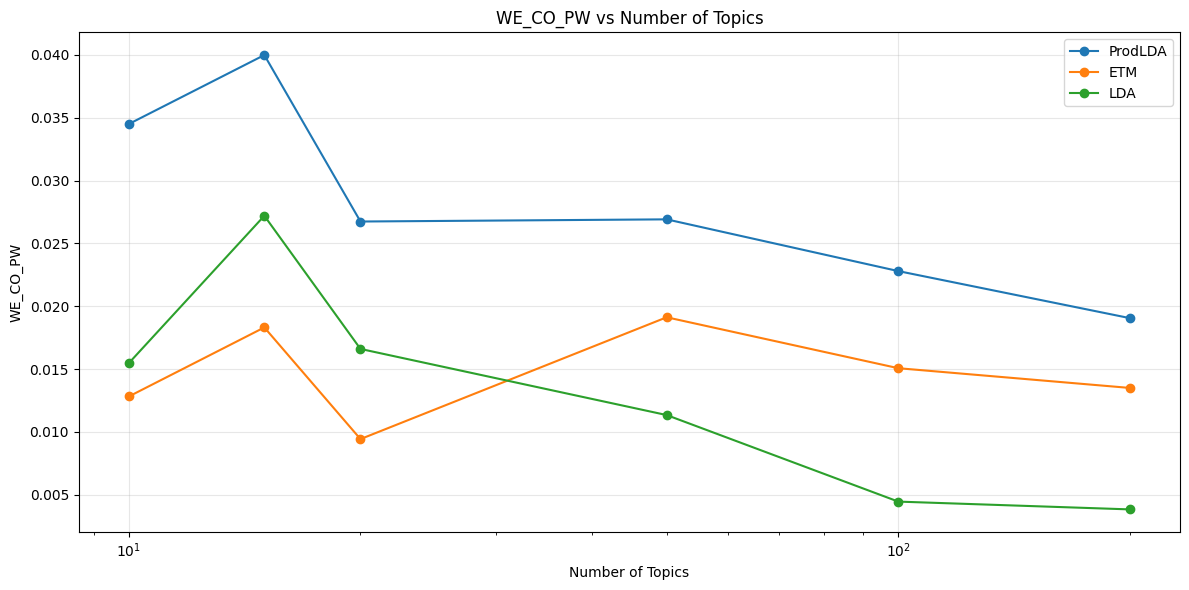

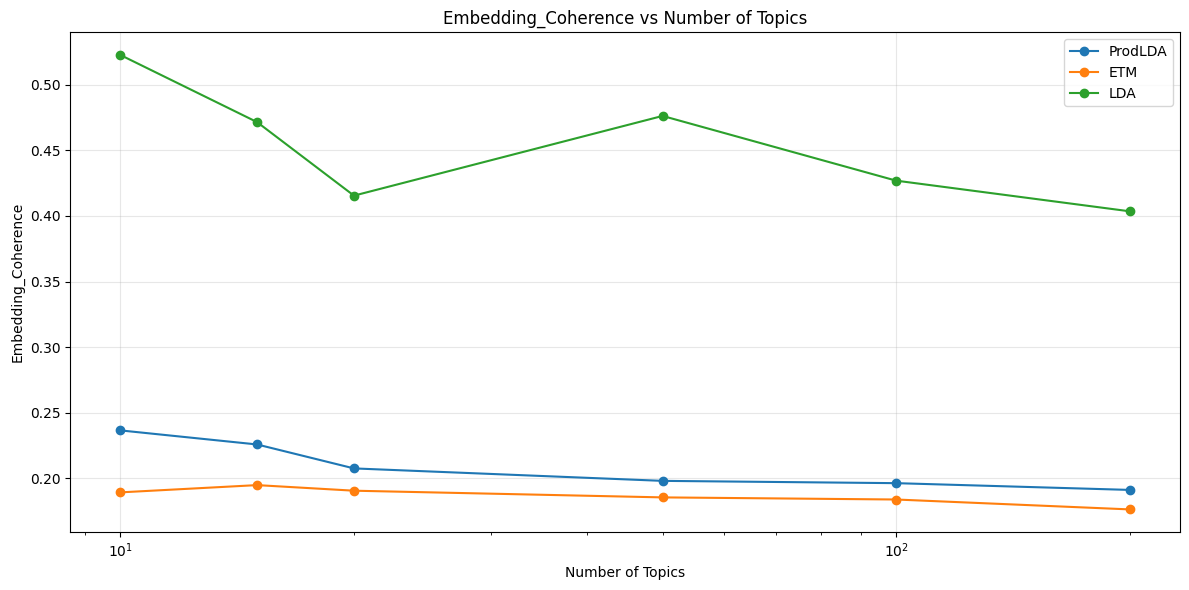

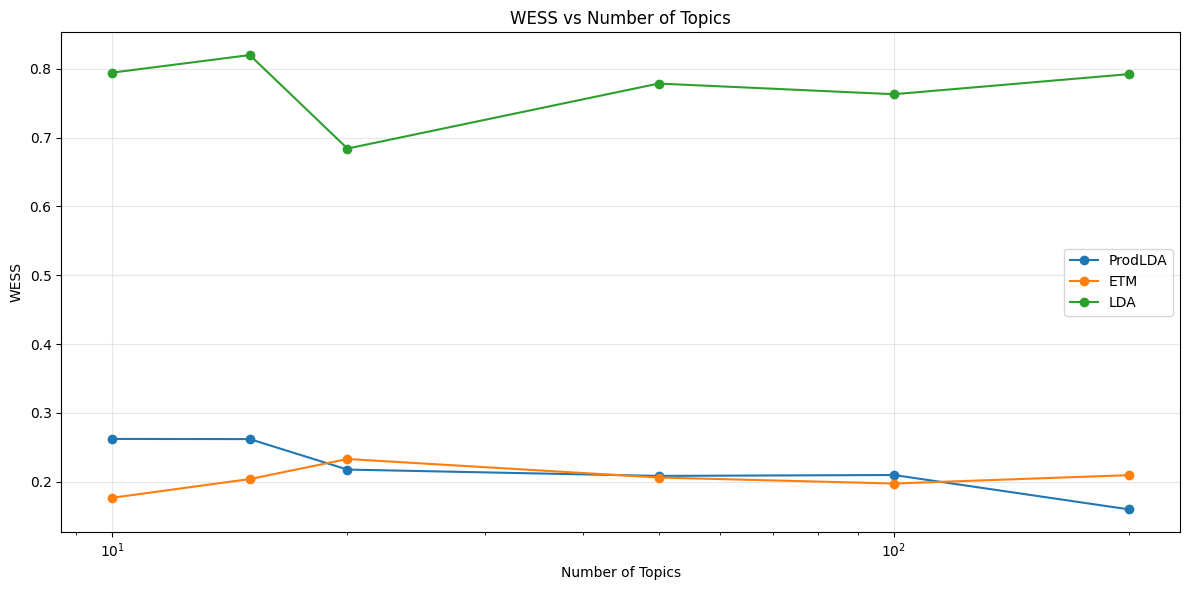

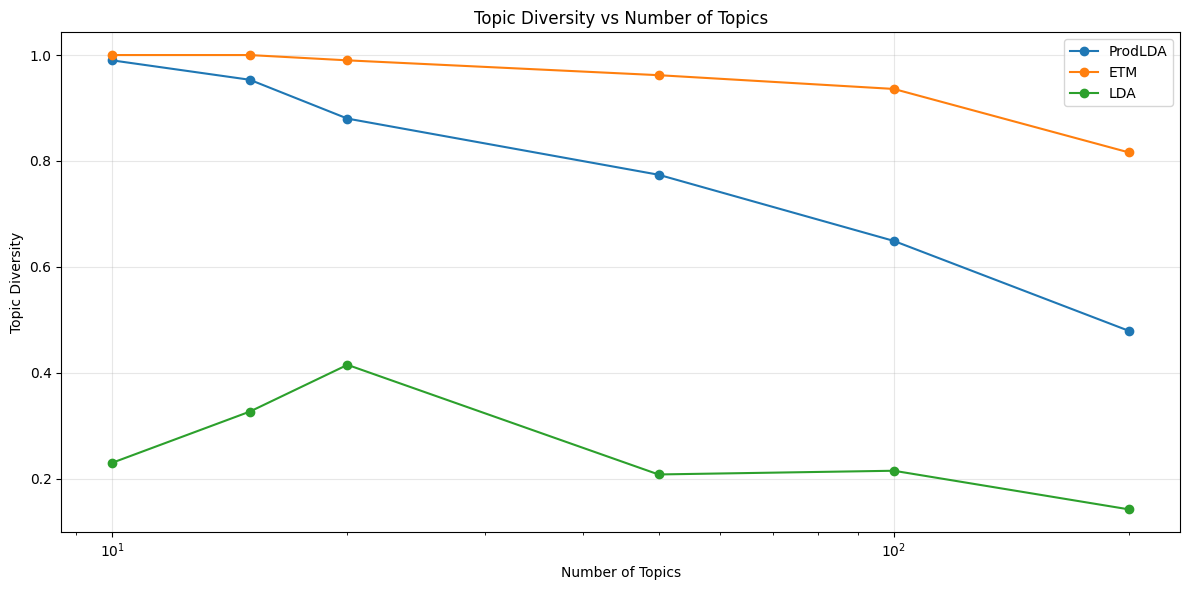

Best values for each model & metric


Metric,Embedding_Coherence,NPMI,Topic Diversity,WESS,WE_CO_PW
Model,,,,,
ETM,0.194820,-0.143866,1.000,0.232911,0.019124
LDA,0.522682,-0.006213,0.415,0.820076,0.027203
ProdLDA,0.236525,-0.005309,0.990,0.262084,0.039996



Number of topics at which the best value occurs


Metric,Embedding_Coherence,NPMI,Topic Diversity,WESS,WE_CO_PW
Model,,,,,
ETM,15,20,10,20,50
LDA,10,20,20,15,15
ProdLDA,10,10,10,10,15


In [33]:
# Visualize and compare results across all models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create a DataFrame to store all results
results_df = pd.DataFrame()

# Process ProdLDA results
for key, value in r.items():
    model_name, n_topic = key
    # Convert model name from class type to string
    model_name_str = (
        model_name.__name__ if hasattr(model_name, "__name__") else str(model_name)
    )
    for metric_name, metric_value in value.items():
        results_df = pd.concat(
            [
                results_df,
                pd.DataFrame(
                    {
                        "Model": [model_name_str],
                        "n_topics": [n_topic],
                        "Metric": [metric_name],
                        "Value": [metric_value],
                    }
                ),
            ]
        )

# Process ETM results
for key, value in r_etm.items():
    model_name, n_topic = key
    # Convert model name from class type to string
    model_name_str = (
        model_name.__name__ if hasattr(model_name, "__name__") else str(model_name)
    )
    for metric_name, metric_value in value.items():
        results_df = pd.concat(
            [
                results_df,
                pd.DataFrame(
                    {
                        "Model": [model_name_str],
                        "n_topics": [n_topic],
                        "Metric": [metric_name],
                        "Value": [metric_value],
                    }
                ),
            ]
        )

# Process LDA results
for key, value in r_lda.items():
    model_name, n_topic = key
    # LDA model names are already strings
    for metric_name, metric_value in value.items():
        results_df = pd.concat(
            [
                results_df,
                pd.DataFrame(
                    {
                        "Model": [model_name],
                        "n_topics": [n_topic],
                        "Metric": [metric_name],
                        "Value": [metric_value],
                    }
                ),
            ]
        )

# Plot results for each metric
metrics = results_df["Metric"].unique()

for metric in metrics:
    plt.figure(figsize=(12, 6))

    # Filter data for this metric
    metric_data = results_df[results_df["Metric"] == metric]

    # Get unique models
    models = metric_data["Model"].unique()

    # Plot each model
    for model in models:
        model_data = metric_data[metric_data["Model"] == model]
        plt.plot(model_data["n_topics"], model_data["Value"], marker="o", label=model)

    plt.title(f"{metric} vs Number of Topics")
    plt.xlabel("Number of Topics")
    plt.ylabel(metric)
    plt.xscale("log")  # Use log scale for x-axis due to wide range of topic numbers
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# Handle the case where there might be duplicate maximum values
# by using pivot_table() instead of pivot()

# First, get the maximum values for each model and metric combination
max_values = results_df.groupby(["Model", "Metric"])["Value"].max().reset_index()

# Then, merge back to get all rows with those maximum values
best_results = pd.merge(
    results_df, max_values, on=["Model", "Metric", "Value"], how="inner"
)

# In case of ties (multiple rows with the same max value),
# take the smallest n_topics value as a tiebreaker
best_results = best_results.sort_values("n_topics").drop_duplicates(["Model", "Metric"])

# One table with the best metric values
if isinstance(best_results, pd.DataFrame) and not best_results.empty:
    best_values = pd.pivot_table(
        best_results,
        index="Model",
        columns="Metric",
        values="Value",
        aggfunc="first",  # In case there are still duplicates
    ).sort_index(axis=1)
else:
    best_values = pd.DataFrame()

# And a second one with the n_topics where that best value occurred
if isinstance(best_results, pd.DataFrame) and not best_results.empty:
    best_topics = pd.pivot_table(
        best_results,
        index="Model",
        columns="Metric",
        values="n_topics",
        aggfunc="first",  # In case there are still duplicates
    ).sort_index(axis=1)
else:
    best_topics = pd.DataFrame()

# Convert topic numbers to integers for cleaner display
if not best_topics.empty:
    best_topics = best_topics.astype(int)

print("Best values for each model & metric")
display(best_values)

print("\nNumber of topics at which the best value occurs")
display(best_topics)
# ------------------------------------------------------------------


NPMI Comparison:
      ProdLDA       ETM       LDA
10  -0.005309 -0.190583 -0.016688
15  -0.021006 -0.160646 -0.012878
20  -0.032679 -0.143866 -0.006213
50  -0.073754 -0.148230 -0.015321
100 -0.128527 -0.193093 -0.024628
200 -0.169462 -0.247890 -0.049756

Word Embedding Coherence Pairwise Comparison:
      ProdLDA       ETM       LDA
10   0.034507  0.012819  0.015473
15   0.039996  0.018316  0.027203
20   0.026745  0.009428  0.016604
50   0.026918  0.019124  0.011340
100  0.022799  0.015070  0.004451
200  0.019054  0.013498  0.003830


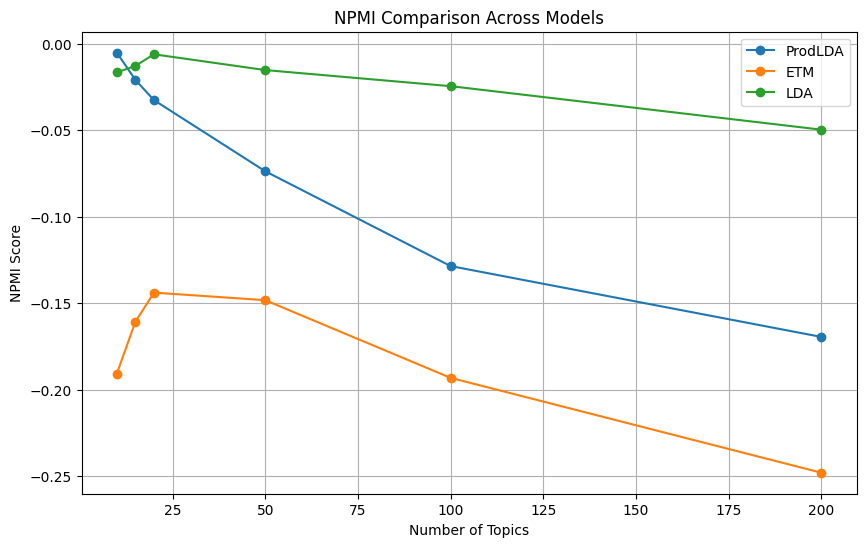

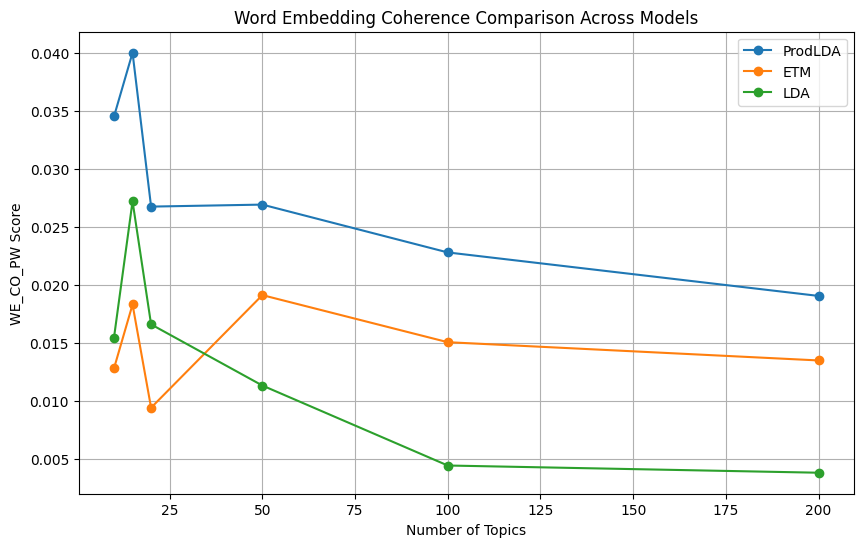

In [31]:
# Compare results across all models
import pandas as pd
import matplotlib.pyplot as plt


# Function to extract results for a specific metric
def extract_metric(results_dict, metric_name):
    data = {}
    for (model, n_topics), metrics in results_dict.items():
        if metric_name in metrics:
            # Convert model class to string if needed
            model_name = model.__name__ if hasattr(model, "__name__") else str(model)
            if model_name not in data:
                data[model_name] = {}
            data[model_name][n_topics] = metrics[metric_name]
    return data


# Extract NPMI scores for all models
npmi_prodlda = {n_topics: metrics["NPMI"] for (model, n_topics), metrics in r.items()}
npmi_etm = {n_topics: metrics["NPMI"] for (model, n_topics), metrics in r_etm.items()}
npmi_lda = {n_topics: metrics["NPMI"] for (model, n_topics), metrics in r_lda.items()}

# Create DataFrame for NPMI comparison
npmi_df = pd.DataFrame(
    {
        "ProdLDA": pd.Series(npmi_prodlda),
        "ETM": pd.Series(npmi_etm),
        "LDA": pd.Series(npmi_lda),
    }
)

print("NPMI Comparison:")
print(npmi_df)

# Extract WE_CO_PW scores for all models
weco_prodlda = {
    n_topics: metrics["WE_CO_PW"] for (model, n_topics), metrics in r.items()
}
weco_etm = {
    n_topics: metrics["WE_CO_PW"] for (model, n_topics), metrics in r_etm.items()
}
weco_lda = {
    n_topics: metrics["WE_CO_PW"] for (model, n_topics), metrics in r_lda.items()
}

# Create DataFrame for WE_CO_PW comparison
weco_df = pd.DataFrame(
    {
        "ProdLDA": pd.Series(weco_prodlda),
        "ETM": pd.Series(weco_etm),
        "LDA": pd.Series(weco_lda),
    }
)

print("\nWord Embedding Coherence Pairwise Comparison:")
print(weco_df)

# Plot NPMI comparison
plt.figure(figsize=(10, 6))
for model in npmi_df.columns:
    plt.plot(npmi_df.index, npmi_df[model], marker="o", label=model)
plt.xlabel("Number of Topics")
plt.ylabel("NPMI Score")
plt.title("NPMI Comparison Across Models")
plt.legend()
plt.grid(True)
plt.show()

# Plot WE_CO_PW comparison
plt.figure(figsize=(10, 6))
for model in weco_df.columns:
    plt.plot(weco_df.index, weco_df[model], marker="o", label=model)
plt.xlabel("Number of Topics")
plt.ylabel("WE_CO_PW Score")
plt.title("Word Embedding Coherence Comparison Across Models")
plt.legend()
plt.grid(True)
plt.show()


In [36]:
# Check available metrics in the results dictionaries
sample_key_prodlda = next(iter(r.keys()))
print("Available metrics in ProdLDA results:", list(r[sample_key_prodlda].keys()))

sample_key_etm = next(iter(r_etm.keys()))
print("Available metrics in ETM results:", list(r_etm[sample_key_etm].keys()))

sample_key_lda = next(iter(r_lda.keys()))
print("Available metrics in LDA results:", list(r_lda[sample_key_lda].keys()))


Available metrics in ProdLDA results: ['NPMI', 'WE_CO_PW', 'Embedding_Coherence', 'WESS', 'Topic Diversity']
Available metrics in ETM results: ['NPMI', 'WE_CO_PW', 'Embedding_Coherence', 'WESS', 'Topic Diversity']
Available metrics in LDA results: ['NPMI', 'WE_CO_PW', 'Embedding_Coherence', 'WESS', 'Topic Diversity']


In [38]:
# Format and print results in the requested table format for each model
import pandas as pd
from tabulate import tabulate

# Define the metrics we want to display based on the available metrics
metrics_to_display = [
    "NPMI",
    "WE_CO_PW",
    "Embedding_Coherence",
    "Topic Diversity",
    "WESS",
]
metric_display_names = {
    "NPMI": "NPMI Coherence",
    "WE_CO_PW": "Embedding Coherence (PW)",
    "Embedding_Coherence": "Embedding Coherence",
    "Topic Diversity": "Topic Diversity",
    "WESS": "Embedding Diversity",
}


# Function to calculate mean and std from multiple runs (if available)
def format_metric_value(values):
    if isinstance(values, list):
        mean_val = np.mean(values)
        std_val = np.std(values)
        return f"{mean_val:.4f} ± {std_val:.4f}"
    else:
        return f"{values:.4f} ± 0.0000"


# Process results for each model
models = ["ProdLDA", "ETM", "LDA"]
all_results = [r, r_etm, r_lda]

for model_idx, model_name in enumerate(models):
    print("=" * 80)
    print(f"Results for {model_name}")
    print("=" * 80)

    # Create a DataFrame to store the results
    results_table = []

    # Get the results for this model
    model_results = all_results[model_idx]

    # For each number of topics
    for n_topic in sorted(set([nt for (_, nt) in model_results.keys()])):
        row = [n_topic]

        # For each metric
        for metric in metrics_to_display:
            # Get the value for this metric and topic number
            if model_idx < 2:  # ProdLDA and ETM
                key = (
                    next(m for m in model_results.keys() if m[1] == n_topic)[0],
                    n_topic,
                )
            else:  # LDA
                key = (model_name, n_topic)

            if key in model_results and metric in model_results[key]:
                value = model_results[key][metric]
                row.append(format_metric_value(value))
            else:
                row.append("N/A")

        results_table.append(row)

    # Create the table headers
    headers = ["n_topics"] + [metric_display_names[m] for m in metrics_to_display]

    # Print the table
    print(tabulate(results_table, headers=headers, tablefmt="grid"))
    print("\n")


Results for ProdLDA
+------------+------------------+----------------------------+-----------------------+-------------------+-----------------------+
|   n_topics | NPMI Coherence   | Embedding Coherence (PW)   | Embedding Coherence   | Topic Diversity   | Embedding Diversity   |
+============+==================+============================+=======================+===================+=======================+
|         10 | -0.0053 ± 0.0000 | 0.0345 ± 0.0000            | 0.2365 ± 0.0000       | 0.9900 ± 0.0000   | 0.2621 ± 0.0000       |
+------------+------------------+----------------------------+-----------------------+-------------------+-----------------------+
|         15 | -0.0210 ± 0.0000 | 0.0400 ± 0.0000            | 0.2258 ± 0.0000       | 0.9533 ± 0.0000   | 0.2618 ± 0.0000       |
+------------+------------------+----------------------------+-----------------------+-------------------+-----------------------+
|         20 | -0.0327 ± 0.0000 | 0.0267 ± 0.0000            | 